# Traffic Demand Prediction

"
            "This notebook builds and compares multiple regression models to predict urban passenger traffic demand.

"
            "Models benchmarked:
"
            "- Random Forest Regressor
"
            "- Gradient Boosting Regressor
"
            "- XGBoost Regressor
"
            "- LightGBM Regressor

"
            "Evaluation metric: **R2 Score** on a validation split.
"
            

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 120)


In [2]:
# Load data
train_path = 'dataset/train.csv'
test_path = 'dataset/test.csv'
sample_sub_path = 'dataset/sample_submission.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)
sample_sub = pd.read_csv(sample_sub_path)

print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)
print('Sample submission shape:', sample_sub.shape)

display(train_df.head())
display(test_df.head())


Train shape: (77299, 11)
Test shape : (41778, 10)
Sample submission shape: (5, 2)


,Index,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,48,0:0,0.048804,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02zt,48,0:0,0.118507,Residential,3,Allowed,Yes,31.104565,Sunny
2,2,qp08bj,48,0:0,0.027132,Residential,1,Not Allowed,No,25.919267,Sunny
3,3,qp08gt,48,0:0,0.003272,Residential,1,Not Allowed,No,NaN,Rainy
4,4,qp02zq,48,0:0,0.010819,Residential,1,Not Allowed,No,10.803667,Rainy


,Index,geohash,day,timestamp,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
0,0,qp02z1,49,2:15,NaN,1,Not Allowed,No,NaN,NaN
1,1,qp02z9,49,2:15,Residential,1,Not Allowed,No,6.476213,Snowy
2,2,qp02yf,49,2:15,Residential,3,Allowed,Yes,22.318203,Sunny
3,3,qp02z6,49,2:15,Residential,2,Not Allowed,Yes,NaN,Rainy
4,4,qp02zd,49,2:15,Residential,1,Not Allowed,No,18.266162,Foggy


In [3]:
# Basic structure and missing values
print('Train dtypes:')
display(train_df.dtypes)

missing_train = train_df.isna().mean().mul(100).sort_values(ascending=False)
missing_test = test_df.isna().mean().mul(100).sort_values(ascending=False)

print('Missing % (train):')
display(missing_train.to_frame('missing_pct'))
print('Missing % (test):')
display(missing_test.to_frame('missing_pct'))


Train dtypes:


Index              int64
geohash           object
day                int64
timestamp         object
demand           float64
RoadType          object
NumberofLanes      int64
LargeVehicles     object
Landmarks         object
Temperature      float64
Weather           object
dtype: object

Missing % (train):


,missing_pct
Temperature,3.227726
Weather,1.031061
RoadType,0.776207
day,0.000000
geohash,0.000000
Index,0.000000
timestamp,0.000000
NumberofLanes,0.000000
demand,0.000000
Landmarks,0.000000


Missing % (test):


,missing_pct
Temperature,3.228972
Weather,1.031643
RoadType,0.775528
Index,0.000000
geohash,0.000000
day,0.000000
NumberofLanes,0.000000
timestamp,0.000000
Landmarks,0.000000
LargeVehicles,0.000000


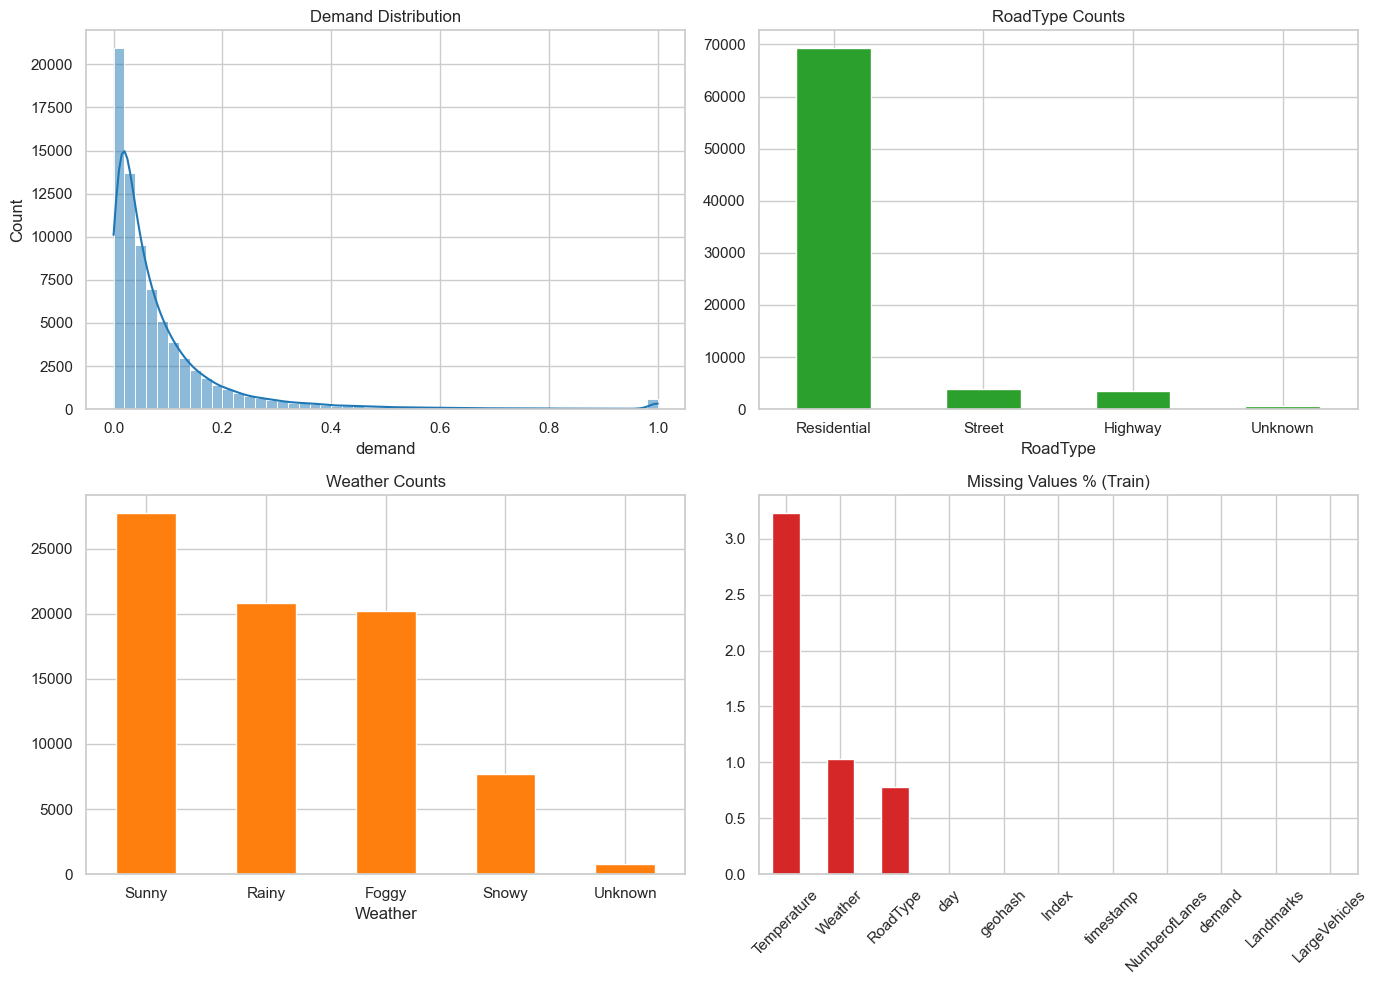

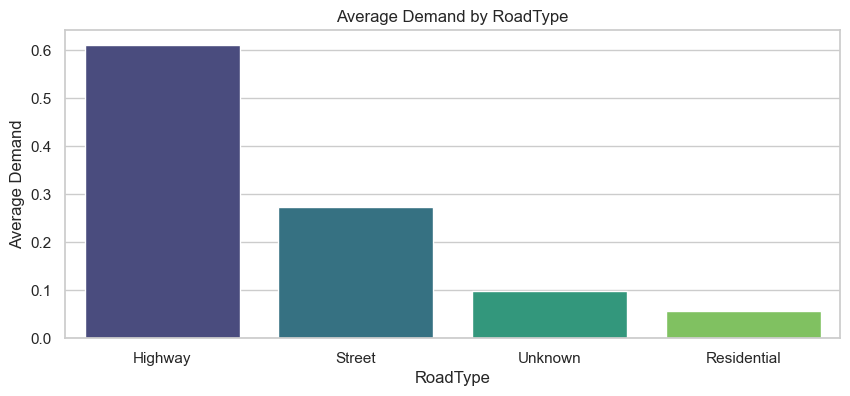

In [4]:
# EDA visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.histplot(train_df['demand'], bins=50, kde=True, ax=axes[0, 0], color='#1f77b4')
axes[0, 0].set_title('Demand Distribution')

train_df['RoadType'].fillna('Unknown').value_counts().plot(kind='bar', ax=axes[0, 1], color='#2ca02c')
axes[0, 1].set_title('RoadType Counts')
axes[0, 1].tick_params(axis='x', rotation=0)

train_df['Weather'].fillna('Unknown').value_counts().plot(kind='bar', ax=axes[1, 0], color='#ff7f0e')
axes[1, 0].set_title('Weather Counts')
axes[1, 0].tick_params(axis='x', rotation=0)

missing_train.plot(kind='bar', ax=axes[1, 1], color='#d62728')
axes[1, 1].set_title('Missing Values % (Train)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
road_demand = train_df.groupby('RoadType', dropna=False)['demand'].mean().sort_values(ascending=False)
road_demand.index = road_demand.index.fillna('Unknown')
sns.barplot(x=road_demand.index, y=road_demand.values, palette='viridis')
plt.title('Average Demand by RoadType')
plt.xlabel('RoadType')
plt.ylabel('Average Demand')
plt.show()


## Feature Engineering and Preprocessing

"
            "Features include:
"
            "- Temporal extraction from `timestamp` (hour, minute, slot, cyclical encoding)
"
            "- Binary encoding of `LargeVehicles` and `Landmarks`
"
            "- Geohash spatial encodings (prefix frequency + smoothed target encoding)
"
            "- Interaction features across temperature, lanes, and road traits
"
            "- Robust imputation and clipping of `Temperature`
"
            

In [5]:
class TrafficFeatureEngineer:
    def __init__(self, smoothing=25):
        self.smoothing = smoothing
        self.global_target = None
        self.global_temp_median = None
        self.temp_group_median = None
        self.weather_temp_median = None
        self.temp_clip_low = None
        self.temp_clip_high = None
        self.road_map = None
        self.weather_map = None
        self.road_unknown_code = None
        self.weather_unknown_code = None
        self.geohash_freq = None
        self.geo3_freq = None
        self.geo4_freq = None
        self.geohash_te = None
        self.geo3_te = None
        self.geo4_te = None
        self.geo_hour_te = None
        self.hour_prior = None
        self.slot_prior = None
        self.road_weather_te = None
        self.feature_cols = None

    def _base_features(self, df: pd.DataFrame) -> pd.DataFrame:
        data = df.copy()
        data['RoadType'] = data['RoadType'].fillna('Unknown')
        data['Weather'] = data['Weather'].fillna('Unknown')

        hm = data['timestamp'].str.split(':', expand=True).astype(int)
        data['hour'] = hm[0]
        data['minute'] = hm[1]
        data['time_slot'] = data['hour'] * 4 + (data['minute'] // 15)

        data['hour_sin'] = np.sin(2 * np.pi * data['hour'] / 24)
        data['hour_cos'] = np.cos(2 * np.pi * data['hour'] / 24)
        data['slot_sin'] = np.sin(2 * np.pi * data['time_slot'] / 96)
        data['slot_cos'] = np.cos(2 * np.pi * data['time_slot'] / 96)

        data['day_mod7'] = data['day'] % 7
        data['is_weekend'] = data['day_mod7'].isin([5, 6]).astype(int)
        data['is_peak_hour'] = data['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

        data['LargeVehicles_bin'] = data['LargeVehicles'].map({'Allowed': 1, 'Not Allowed': 0}).fillna(0).astype(int)
        data['Landmarks_bin'] = data['Landmarks'].map({'Yes': 1, 'No': 0}).fillna(0).astype(int)
        data['temp_missing'] = data['Temperature'].isna().astype(int)

        data['geo3'] = data['geohash'].str[:3]
        data['geo4'] = data['geohash'].str[:4]

        return data

    def _smooth_target_map(self, keys: pd.Series, y: pd.Series) -> dict:
        temp = pd.DataFrame({'key': keys, 'target': y.values})
        stats = temp.groupby('key')['target'].agg(['mean', 'count'])
        enc = (stats['mean'] * stats['count'] + self.smoothing * self.global_target) / (stats['count'] + self.smoothing)
        return enc.to_dict()

    def fit(self, X: pd.DataFrame, y: pd.Series):
        base = self._base_features(X)
        self.global_target = float(y.mean())
        self.global_temp_median = float(base['Temperature'].median())

        self.temp_group_median = base.groupby(['Weather', 'RoadType'])['Temperature'].median()
        self.weather_temp_median = base.groupby('Weather')['Temperature'].median().to_dict()
        self.temp_clip_low = float(base['Temperature'].quantile(0.01))
        self.temp_clip_high = float(base['Temperature'].quantile(0.99))

        road_categories = sorted(base['RoadType'].unique())
        weather_categories = sorted(base['Weather'].unique())
        self.road_map = {v: i for i, v in enumerate(road_categories)}
        self.weather_map = {v: i for i, v in enumerate(weather_categories)}
        self.road_unknown_code = len(self.road_map)
        self.weather_unknown_code = len(self.weather_map)

        self.geohash_freq = base['geohash'].value_counts(normalize=True).to_dict()
        self.geo3_freq = base['geo3'].value_counts(normalize=True).to_dict()
        self.geo4_freq = base['geo4'].value_counts(normalize=True).to_dict()

        self.geohash_te = self._smooth_target_map(base['geohash'], y)
        self.geo3_te = self._smooth_target_map(base['geo3'], y)
        self.geo4_te = self._smooth_target_map(base['geo4'], y)

        geo_hour_key = base['geohash'] + '_' + base['hour'].astype(str)
        self.geo_hour_te = self._smooth_target_map(geo_hour_key, y)

        temp = pd.DataFrame({
            'hour': base['hour'],
            'time_slot': base['time_slot'],
            'RoadType': base['RoadType'],
            'Weather': base['Weather'],
            'target': y.values,
        })
        self.hour_prior = temp.groupby('hour')['target'].mean().to_dict()
        self.slot_prior = temp.groupby('time_slot')['target'].mean().to_dict()

        rw_keys = temp['RoadType'] + '_' + temp['Weather']
        self.road_weather_te = self._smooth_target_map(rw_keys, y)

        self.feature_cols = [
            'day', 'day_mod7', 'hour', 'minute', 'time_slot',
            'hour_sin', 'hour_cos', 'slot_sin', 'slot_cos',
            'is_weekend', 'is_peak_hour',
            'NumberofLanes', 'LargeVehicles_bin', 'Landmarks_bin',
            'Temperature', 'temp_missing',
            'RoadType_enc', 'Weather_enc', 'is_highway',
            'geohash_freq', 'geo3_freq', 'geo4_freq',
            'geohash_te', 'geo3_te', 'geo4_te', 'geo_hour_te',
            'hour_prior', 'slot_prior', 'road_weather_prior',
            'temp_x_lanes', 'temp_x_highway',
            'lanes_x_landmarks', 'lanes_x_largevehicle',
            'weather_temp_dev',
        ]
        return self

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        base = self._base_features(X)

        group_index = pd.MultiIndex.from_frame(base[['Weather', 'RoadType']])
        group_median = pd.Series(group_index.map(self.temp_group_median), index=base.index, dtype='float64')
        weather_median = base['Weather'].map(self.weather_temp_median)

        base['Temperature'] = base['Temperature'].fillna(group_median)
        base['Temperature'] = base['Temperature'].fillna(weather_median)
        base['Temperature'] = base['Temperature'].fillna(self.global_temp_median)
        base['Temperature'] = base['Temperature'].clip(self.temp_clip_low, self.temp_clip_high)

        base['RoadType_enc'] = base['RoadType'].map(self.road_map).fillna(self.road_unknown_code).astype(int)
        base['Weather_enc'] = base['Weather'].map(self.weather_map).fillna(self.weather_unknown_code).astype(int)
        base['is_highway'] = (base['RoadType'] == 'Highway').astype(int)

        base['geohash_freq'] = base['geohash'].map(self.geohash_freq).fillna(0.0)
        base['geo3_freq'] = base['geo3'].map(self.geo3_freq).fillna(0.0)
        base['geo4_freq'] = base['geo4'].map(self.geo4_freq).fillna(0.0)

        base['geohash_te'] = base['geohash'].map(self.geohash_te).fillna(self.global_target)
        base['geo3_te'] = base['geo3'].map(self.geo3_te).fillna(self.global_target)
        base['geo4_te'] = base['geo4'].map(self.geo4_te).fillna(self.global_target)

        geo_hour_key = base['geohash'] + '_' + base['hour'].astype(str)
        base['geo_hour_te'] = geo_hour_key.map(self.geo_hour_te).fillna(base['geohash_te'])

        base['hour_prior'] = base['hour'].map(self.hour_prior).fillna(self.global_target)
        base['slot_prior'] = base['time_slot'].map(self.slot_prior).fillna(self.global_target)
        rw_key = base['RoadType'] + '_' + base['Weather']
        base['road_weather_prior'] = rw_key.map(self.road_weather_te).fillna(self.global_target)

        base['temp_x_lanes'] = base['Temperature'] * base['NumberofLanes']
        base['temp_x_highway'] = base['Temperature'] * base['is_highway']
        base['lanes_x_landmarks'] = base['NumberofLanes'] * base['Landmarks_bin']
        base['lanes_x_largevehicle'] = base['NumberofLanes'] * base['LargeVehicles_bin']
        base['weather_temp_dev'] = base['Temperature'] - base['Weather'].map(self.weather_temp_median).fillna(self.global_temp_median)

        features = base[self.feature_cols].copy()
        features = features.replace([np.inf, -np.inf], np.nan)
        features = features.fillna(self.global_target)
        return features.astype(float)


In [6]:
# Train-validation split
X = train_df.drop(columns=['demand'])
y = train_df['demand'].copy()
X_test_raw = test_df.copy()

X_train_raw, X_valid_raw, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

fe = TrafficFeatureEngineer(smoothing=25)
fe.fit(X_train_raw, y_train)

X_train_fe = fe.transform(X_train_raw)
X_valid_fe = fe.transform(X_valid_raw)
X_test_fe = fe.transform(X_test_raw)

print('Feature matrix shape (train):', X_train_fe.shape)
print('Feature matrix shape (valid):', X_valid_fe.shape)
print('Feature matrix shape (test): ', X_test_fe.shape)


Feature matrix shape (train): (61839, 34)
Feature matrix shape (valid): (15460, 34)
Feature matrix shape (test):  (41778, 34)


In [7]:
# Model training and evaluation
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def get_models(seed=42):
    return {
        'RandomForest': RandomForestRegressor(
            n_estimators=500,
            min_samples_leaf=2,
            random_state=seed,
            n_jobs=-1,
        ),
        'GradientBoosting': GradientBoostingRegressor(
            n_estimators=600,
            learning_rate=0.03,
            max_depth=4,
            subsample=0.85,
            random_state=seed,
        ),
        'XGBoost': XGBRegressor(
            n_estimators=900,
            learning_rate=0.03,
            max_depth=8,
            subsample=0.85,
            colsample_bytree=0.85,
            reg_lambda=1.0,
            objective='reg:squarederror',
            random_state=seed,
            n_jobs=-1,
        ),
        'LightGBM': LGBMRegressor(
            n_estimators=1200,
            learning_rate=0.03,
            num_leaves=63,
            subsample=0.85,
            colsample_bytree=0.85,
            random_state=seed,
            n_jobs=-1,
        ),
    }


models = get_models(RANDOM_STATE)
results = []
fitted_models = {}

for name, model in models.items():
    model.fit(X_train_fe, y_train)
    pred = np.clip(model.predict(X_valid_fe), 0.0, 1.0)

    row = {
        'Model': name,
        'R2': r2_score(y_valid, pred),
        'MAE': mean_absolute_error(y_valid, pred),
        'RMSE': rmse(y_valid, pred),
    }
    results.append(row)
    fitted_models[name] = model
    print(f"{name:<18} | R2={row['R2']:.6f} | MAE={row['MAE']:.6f} | RMSE={row['RMSE']:.6f}")

results_df = pd.DataFrame(results).sort_values('R2', ascending=False).reset_index(drop=True)
display(results_df)

best_model_name = results_df.loc[0, 'Model']
print('Best model based on validation R2:', best_model_name)


RandomForest       | R2=0.939856 | MAE=0.021300 | RMSE=0.034885
GradientBoosting   | R2=0.935046 | MAE=0.022559 | RMSE=0.036254
XGBoost            | R2=0.941801 | MAE=0.021414 | RMSE=0.034316
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005869 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2130
[LightGBM] [Info] Number of data points in the train set: 61839, number of used features: 32
[LightGBM] [Info] Start training from score 0.093784
LightGBM           | R2=0.940183 | MAE=0.021680 | RMSE=0.034790


,Model,R2,MAE,RMSE
0,XGBoost,0.941801,0.021414,0.034316
1,LightGBM,0.940183,0.021680,0.034790
2,RandomForest,0.939856,0.021300,0.034885
3,GradientBoosting,0.935046,0.022559,0.036254


Best model based on validation R2: XGBoost


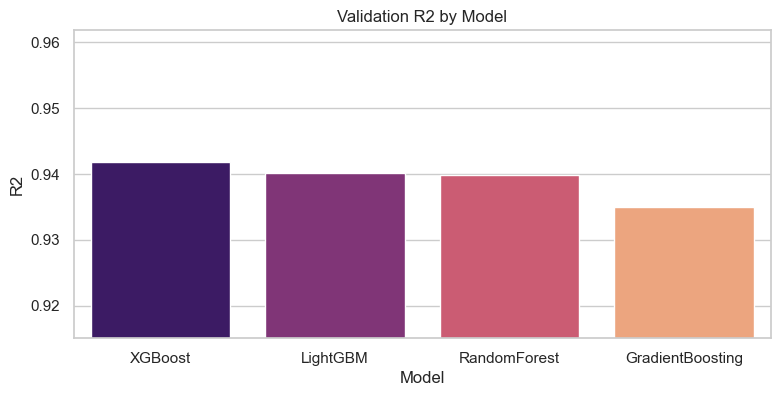

In [8]:
# Model comparison chart
plt.figure(figsize=(9, 4))
sns.barplot(data=results_df, x='Model', y='R2', palette='magma')
plt.title('Validation R2 by Model')
plt.ylim(results_df['R2'].min() - 0.02, results_df['R2'].max() + 0.02)
plt.show()


In [9]:
# Retrain best model on full training data and predict test
fe_full = TrafficFeatureEngineer(smoothing=25)
fe_full.fit(X, y)

X_full_fe = fe_full.transform(X)
X_test_full_fe = fe_full.transform(X_test_raw)

final_model = get_models(RANDOM_STATE)[best_model_name]
final_model.fit(X_full_fe, y)

test_pred = np.clip(final_model.predict(X_test_full_fe), 0.0, 1.0)

submission = pd.DataFrame({
    'Index': test_df['Index'],
    'demand': test_pred,
})

submission_path = 'submission_best_model.csv'
submission.to_csv(submission_path, index=False)

print('Submission saved to:', submission_path)
print('Submission shape:', submission.shape)
print('Columns:', submission.columns.tolist())
display(submission.head())


Submission saved to: submission_best_model.csv
Submission shape: (41778, 2)
Columns: ['Index', 'demand']


,Index,demand
0,0,0.061555
1,1,0.027027
2,2,0.034695
3,3,0.064550
4,4,0.058499


In [10]:
# Final checks
assert submission.shape == (41778, 2), 'Submission shape is incorrect.'
assert submission.columns.tolist() == ['Index', 'demand'], 'Submission columns are incorrect.'
assert np.issubdtype(submission['demand'].dtype, np.number), 'demand must be numeric.'

print('All checks passed.')


All checks passed.
